# Modelo de Previsão de Preço Contratual

## 0. Imports e carregamento de dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)
from sklearn.model_selection import KFold, train_test_split
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.stats import f_oneway
from sklearn.inspection import permutation_importance
import seaborn as sns

df = pd.read_csv("contratos_limpo.csv", low_memory=False)
print(f"Linhas: {len(df):,} | Colunas: {df.shape[1]}")


Linhas: 1,803,493 | Colunas: 35


In [2]:
df.columns

Index(['idcontrato', 'tipoContrato', 'idprocedimento', 'tipoprocedimento',
       'objectoContrato', 'descContrato', 'adjudicante', 'adjudicatarios',
       'dataPublicacao', 'dataCelebracaoContrato', 'precoContratual', 'CPV',
       'prazoExecucao', 'LocalExecucao', 'fundamentacao',
       'ProcedimentoCentralizado', 'DescrAcordoQuadro',
       'dataDecisaoAdjudicacao', 'regime', 'justifNReducEscrContrato',
       'CritMateriais', 'concorrentes', 'linkPecasProc', 'Observacoes',
       'ContratEcologico', 'fundamentAjusteDireto', 'Ano', 'ano_contrato',
       'precoContratual_2025', 'setor_cpv', 'descricao_cpv',
       'racio_preco_prazo', 'janela_eleicoes', 'AR', 'AL'],
      dtype='object')

## 1. Target e feature engineering

In [3]:
#TARGET
target_col = "precoContratual_2025"
df = df[df[target_col].notna() & (df[target_col] > 0)].copy()

# DATAS 
df["dataPublicacao"] = pd.to_datetime(df["dataPublicacao"], errors="coerce")
df["dataDecisaoAdjudicacao"] = pd.to_datetime(df["dataDecisaoAdjudicacao"], errors="coerce")

df["ano_publicacao"] = df["dataPublicacao"].dt.year
df["mes_publicacao"] = df["dataPublicacao"].dt.month

# dias entre decisão de adjudicação e publicação (decisão ocorre antes)
df["dias_publicacao_decisao"] = (
    (df["dataDecisaoAdjudicacao"] - df["dataPublicacao"])
    .dt.days
    .abs()
    .clip(lower=0)
)

# CONCORRENTES 
if "concorrentes" in df.columns:
    df["n_concorrentes"] = df["concorrentes"].fillna("").apply(
        lambda x: len([v for v in str(x).split("\n") if v.strip()])
    )
else:
    df["n_concorrentes"] = 0
df["n_concorrentes"] = df["n_concorrentes"].fillna(0)

# PRAZO
df["log_prazoExecucao"] = np.log1p(df["prazoExecucao"].clip(lower=0))
df["contrato_longo"]    = (df["prazoExecucao"] > 365).astype(int)
df["contrato_curto"]    = (df["prazoExecucao"] <= 30).astype(int)

#FLAGS
df["fim_ano"] = df["mes_publicacao"].isin([11, 12]).astype(int)

df["is_ajuste_direto"] = (
    df["tipoprocedimento"].astype(str).str.upper().str.contains("AJUSTE", na=False)
).astype(int)

df["is_concurso_publico"] = (
    df["tipoprocedimento"].astype(str).str.upper().str.contains("CONCURSO", na=False)
).astype(int)

df["tem_acordo_quadro"] = df["DescrAcordoQuadro"].notna().astype(int)


#CPV
df["cpv_str"] = df["CPV"].astype(str).str.extract(r"(\d+)", expand=False)

df["cpv_3"] = df["cpv_str"].str[:3]
df["cpv_4"] = df["cpv_str"].str[:4]




In [4]:
pd.set_option("display.max_rows", None)

df["tipoprocedimento"] \
    .astype(str) \
    .str.strip() \
    .str.upper() \
    .value_counts(dropna=False)

tipoprocedimento
AJUSTE DIRETO REGIME GERAL                                                      1000297
CONSULTA PRÉVIA                                                                  297667
CONCURSO PÚBLICO                                                                 209153
AO ABRIGO DE ACORDO-QUADRO (ART. 259.)                                           186994
AO ABRIGO DE ACORDO-QUADRO (ART. 258.)                                            40543
AJUSTE DIRETO SIMPLIFICADO                                                        38623
CONTRATAÇÃO EXCLUÍDA II                                                           20063
CONCURSO LIMITADO POR PRÉVIA QUALIFICAÇÃO                                          2877
SETORES ESPECIAIS  ISENÇÃO PARTE II                                                2723
AJUSTE DIRETO SIMPLIFICADO AO ABRIGO DA LEI N. 30/2021, DE 21.05                   2487
CONSULTA PRÉVIA SIMPLIFICADA                                                       1813
CONCURSO PÚBLIC

## 2. Análise exploratória

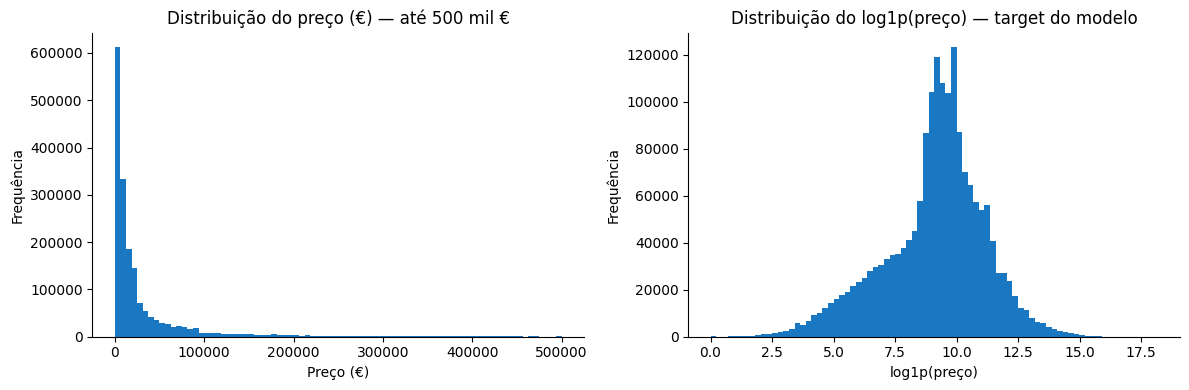

In [5]:
# Distribuição do target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

preco_plot = df.loc[df[target_col] <= 500_000, target_col]
axes[0].hist(preco_plot, bins=80, color='#1a78c2', edgecolor='none')
axes[0].set_title('Distribuição do preço (€) — até 500 mil €')
axes[0].set_xlabel('Preço (€)')
axes[0].set_ylabel('Frequência')

axes[1].hist(np.log1p(df[target_col]), bins=80, color='#1a78c2', edgecolor='none')
axes[1].set_title('Distribuição do log1p(preço) — target do modelo')
axes[1].set_xlabel('log1p(preço)')
axes[1].set_ylabel('Frequência')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


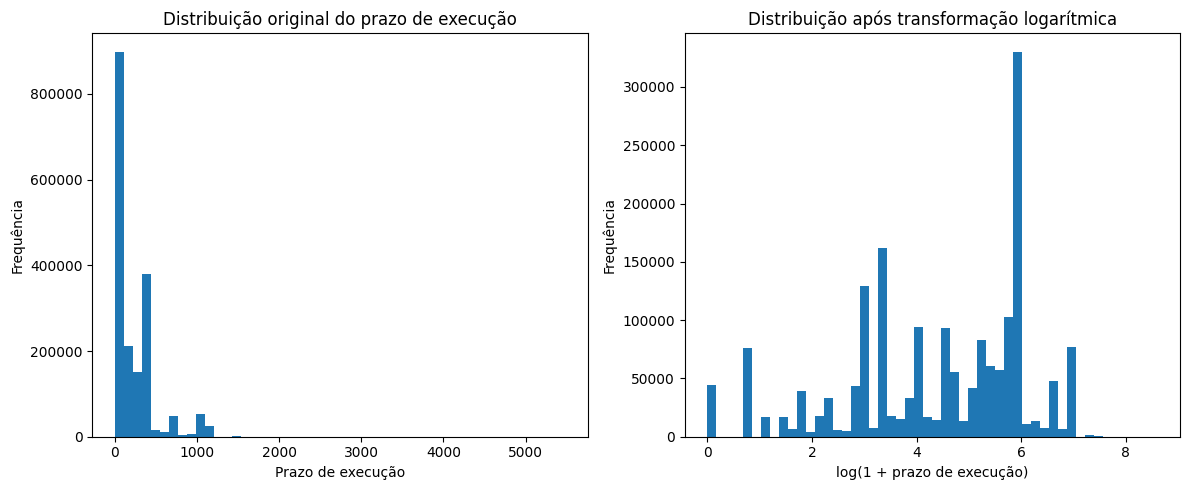

In [19]:


# garantir que não há valores negativos ou nulos problemáticos
df_plot = df[df["prazoExecucao"].notna()].copy()
df_plot = df_plot[df_plot["prazoExecucao"] >= 0]

# criar variável logarítmica
df_plot["log_prazoExecucao"] = np.log1p(df_plot["prazoExecucao"])

plt.figure(figsize=(12, 5))

# Distribuição original
plt.subplot(1, 2, 1)
plt.hist(df_plot["prazoExecucao"], bins=50)
plt.title("Distribuição original do prazo de execução")
plt.xlabel("Prazo de execução")
plt.ylabel("Frequência")

# Distribuição com log
plt.subplot(1, 2, 2)
plt.hist(df_plot["log_prazoExecucao"], bins=50)
plt.title("Distribuição após transformação logarítmica")
plt.xlabel("log(1 + prazo de execução)")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

## 3. Correlação e associação com o target

In [7]:
candidatas_num = [
    "prazoExecucao", "log_prazoExecucao", "n_concorrentes",
    "contrato_longo", "contrato_curto", "ano_publicacao",
    "mes_publicacao", "fim_ano", "dias_publicacao_decisao",
    "tem_acordo_quadro", "is_ajuste_direto", "is_concurso_publico",
]

candidatas_cat = [
    "tipoContrato", "tipoprocedimento", "setor_cpv",
    "ProcedimentoCentralizado", "CritMateriais", "janela_eleicoes",
    "AR", "AL", "fundamentacao", "regime", "ContratEcologico",
    "fundamentAjusteDireto","cpv_3","cpv_4",
]

candidatas_num = [c for c in candidatas_num if c in df.columns]
candidatas_cat = [c for c in candidatas_cat if c in df.columns]

df_eda = df.copy()
df_eda["log_target"] = np.log1p(df_eda[target_col])


In [8]:
# Correlação com variáveis numéricas
corr_pearson = (
    df_eda[candidatas_num + ["log_target"]]
    .corr(method="pearson")["log_target"]
    .drop("log_target")
    .sort_values(ascending=False)
)
corr_spearman = (
    df_eda[candidatas_num + ["log_target"]]
    .corr(method="spearman")["log_target"]
    .drop("log_target")
    .sort_values(ascending=False)
)

corr_df = pd.DataFrame({"Pearson": corr_pearson, "Spearman": corr_spearman})
print(corr_df.to_string())


                          Pearson  Spearman
ano_publicacao          -0.014866 -0.020960
contrato_curto          -0.312563 -0.310761
contrato_longo           0.187586  0.192705
dias_publicacao_decisao -0.023144  0.049216
fim_ano                 -0.006571 -0.004067
is_ajuste_direto        -0.197051 -0.218811
is_concurso_publico      0.272062  0.272297
log_prazoExecucao        0.335411  0.303013
mes_publicacao           0.010650  0.015578
n_concorrentes           0.017003  0.167922
prazoExecucao            0.246880  0.303013
tem_acordo_quadro       -0.110818 -0.106811


In [9]:
# ANOVA — associação entre variáveis categóricas e o target
anova_results = []
for col in candidatas_cat:
    grupos = [
        grupo["log_target"].dropna()
        for _, grupo in df_eda.groupby(col)
        if len(grupo) > 30
    ]
    f_stat, p_value = f_oneway(*grupos) if len(grupos) > 1 else (np.nan, np.nan)
    anova_results.append({
        "variavel": col,
        "F_stat": f_stat,
        "p_value": p_value,
        "n_categorias": df_eda[col].nunique()
    })

anova_df = pd.DataFrame(anova_results).sort_values("F_stat", ascending=False)
anova_df


,variavel,F_stat,p_value,n_categorias
4,CritMateriais,95225.486221,0.000000e+00,2
1,tipoprocedimento,19325.767274,0.000000e+00,20
0,tipoContrato,9805.032292,0.000000e+00,60
2,setor_cpv,7583.575729,0.000000e+00,45
10,ContratEcologico,4701.757296,0.000000e+00,2
3,ProcedimentoCentralizado,4131.155110,0.000000e+00,2
8,fundamentacao,2789.374253,0.000000e+00,248
9,regime,2354.188983,0.000000e+00,56
12,cpv_3,1580.075227,0.000000e+00,317
13,cpv_4,583.794914,0.000000e+00,1248


In [10]:
# Eta^2 — proporção da variância explicada por cada categórica
def eta_squared(df, cat_col, target_col):
    temp = df[[cat_col, target_col]].dropna()
    grand_mean = temp[target_col].mean()
    ss_between = temp.groupby(cat_col)[target_col].apply(
        lambda x: len(x) * (x.mean() - grand_mean) ** 2
    ).sum()
    ss_total = ((temp[target_col] - grand_mean) ** 2).sum()
    return ss_between / ss_total if ss_total != 0 else np.nan

eta_results = [
    {"variavel": col, "eta_squared": eta_squared(df_eda, col, "log_target"),
     "n_categorias": df_eda[col].nunique()}
    for col in candidatas_cat
]
eta_df = pd.DataFrame(eta_results).sort_values("eta_squared", ascending=False)
eta_df


,variavel,eta_squared,n_categorias
13,cpv_4,0.231596,1248
12,cpv_3,0.205987,317
8,fundamentacao,0.178642,248
2,setor_cpv,0.156136,45
1,tipoprocedimento,0.130478,20
0,tipoContrato,0.098130,60
4,CritMateriais,0.050153,2
9,regime,0.029310,56
10,ContratEcologico,0.002600,2
3,ProcedimentoCentralizado,0.002285,2


## 4. Preparação do modelo

In [11]:
features_num = [
    "log_prazoExecucao",
    "is_concurso_publico",
    "contrato_longo",
    "n_concorrentes",
    "is_ajuste_direto",
    "tem_acordo_quadro",
    "dias_publicacao_decisao",

]

features_cat = [
    "setor_cpv",
    "tipoprocedimento",
    "tipoContrato",
    "CritMateriais",
    "fundamentacao",
    "regime",
    "ContratEcologico",
    "cpv_4",
]


features_num = [c for c in features_num if c in df.columns]
features_cat = [c for c in features_cat if c in df.columns]
features = features_num + features_cat

# remover outliers (acima do percentil 99)
limite_superior = df[target_col].quantile(0.99)
df_model = df[df[target_col] <= limite_superior][features + [target_col]].copy()

print(f"Dataset do modelo: {len(df_model):,} linhas | {len(features)} features")
print(f"  Numéricas: {features_num}")
print(f"  Categóricas: {features_cat}")


Dataset do modelo: 1,785,458 linhas | 15 features
  Numéricas: ['log_prazoExecucao', 'is_concurso_publico', 'contrato_longo', 'n_concorrentes', 'is_ajuste_direto', 'tem_acordo_quadro', 'dias_publicacao_decisao']
  Categóricas: ['setor_cpv', 'tipoprocedimento', 'tipoContrato', 'CritMateriais', 'fundamentacao', 'regime', 'ContratEcologico', 'cpv_4']


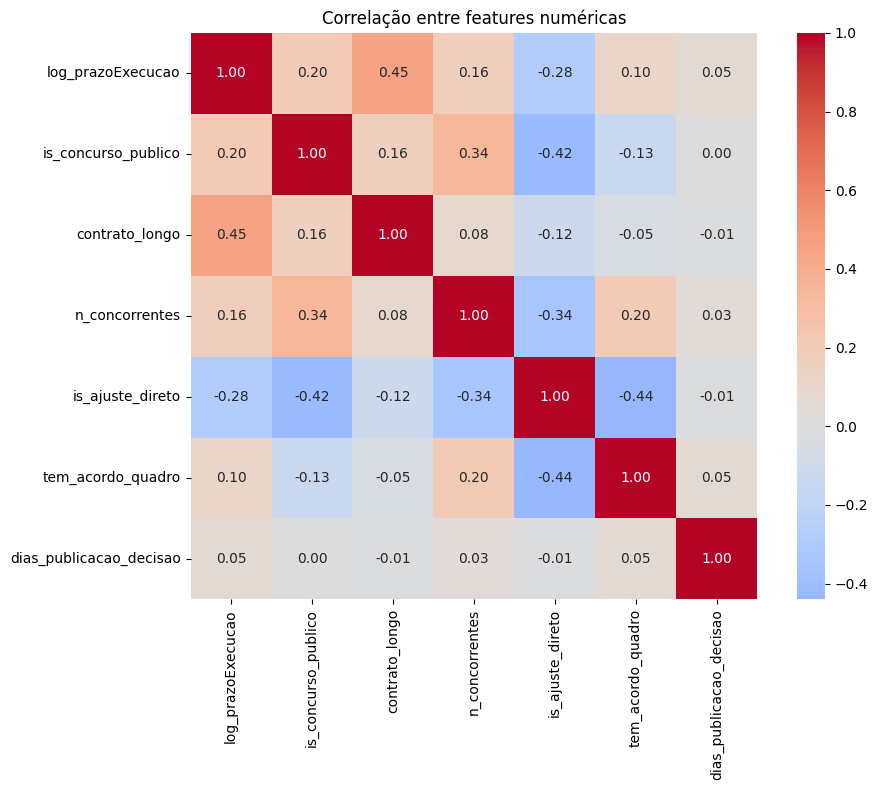

In [12]:

corr_features = df_model[features_num].corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_features,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Correlação entre features numéricas")
plt.tight_layout()
plt.show()

In [13]:
# Split treino / teste
X = df_model[features]
y = np.log1p(df_model[target_col])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
y_test_orig = np.expm1(y_test)

print(f"Treino: {len(X_train):,} | Teste: {len(X_test):,}")

# Preprocessadores
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

categorical_transformer_linear = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("enc", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,   
        max_categories=20     # limita categorias por coluna
    ))
])
# Preprocessador para modelos tree-based (OrdinalEncoder)
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, features_num),
    ("cat", categorical_transformer, features_cat),
])

# Preprocessador para Regressão Linear (OneHotEncoder)
preprocessor_linear = ColumnTransformer([
    ("num", numeric_transformer, features_num),
    ("cat", categorical_transformer_linear, features_cat),
])


Treino: 1,428,366 | Teste: 357,092


## 5. Treino dos modelos

In [14]:
# Regressão Linear
model_lr = Pipeline([
    ("preprocessor", preprocessor_linear),
    ("model", LinearRegression())
])
model_lr.fit(X_train, y_train)

pred_lr_log  = model_lr.predict(X_test)
pred_lr_orig = np.expm1(pred_lr_log)

mae_lr  = mean_absolute_error(y_test_orig, pred_lr_orig)
rmse_lr = np.sqrt(mean_squared_error(y_test_orig, pred_lr_orig))
r2_lr   = r2_score(y_test_orig, pred_lr_orig)

mae_lr_log  = mean_absolute_error(y_test, pred_lr_log)
rmse_lr_log = np.sqrt(mean_squared_error(y_test, pred_lr_log))
r2_lr_log   = r2_score(y_test, pred_lr_log)

print(f"Regressão Linear  | MAE: {mae_lr:,.0f}€ | RMSE: {rmse_lr:,.0f}€ | R^2: {r2_lr:.4f}")


Regressão Linear  | MAE: 27,195€ | RMSE: 70,455€ | R^2: 0.1616


In [15]:
# Random Forest
model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=10,
        max_features=0.5,
        random_state=42,
        n_jobs=-1
    ))
])
model_rf.fit(X_train, y_train)

pred_rf_log  = model_rf.predict(X_test)
pred_rf_orig = np.expm1(pred_rf_log)

y_test_orig  = np.expm1(y_test)
mae_rf  = mean_absolute_error(y_test_orig, pred_rf_orig)
rmse_rf = np.sqrt(mean_squared_error(y_test_orig, pred_rf_orig))
r2_rf   = r2_score(y_test_orig, pred_rf_orig)

mae_rf_log  = mean_absolute_error(y_test, pred_rf_log)
rmse_rf_log = np.sqrt(mean_squared_error(y_test, pred_rf_log))
r2_rf_log   = r2_score(y_test, pred_rf_log)

print(f"Random Forest     | MAE: {mae_rf:,.0f}€ | RMSE: {rmse_rf:,.0f}€ | R^2: {r2_rf:.4f}")


Random Forest     | MAE: 24,246€ | RMSE: 64,415€ | R^2: 0.2992


In [16]:
# HistGradientBoosting
model_hgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.03,
        max_leaf_nodes=63,
        min_samples_leaf=15,
        l2_regularization=0.1,
        random_state=42
    ))
])
model_hgb.fit(X_train, y_train)

pred_hgb_log  = model_hgb.predict(X_test)
pred_hgb_orig = np.expm1(pred_hgb_log)

y_test_orig   = np.expm1(y_test)
mae_hgb  = mean_absolute_error(y_test_orig, pred_hgb_orig)
rmse_hgb = np.sqrt(mean_squared_error(y_test_orig, pred_hgb_orig))
r2_hgb   = r2_score(y_test_orig, pred_hgb_orig)

mae_hgb_log  = mean_absolute_error(y_test, pred_hgb_log)
rmse_hgb_log = np.sqrt(mean_squared_error(y_test, pred_hgb_log))
r2_hgb_log   = r2_score(y_test, pred_hgb_log)

print(f"HGB               | MAE: {mae_hgb:,.0f}€ | RMSE: {rmse_hgb:,.0f}€ | R^2: {r2_hgb:.4f}")


HGB               | MAE: 24,936€ | RMSE: 66,063€ | R^2: 0.2628


## 6. Comparação de modelos

In [17]:
resultados = pd.DataFrame({
    "Modelo":        ["Regressão Linear", "Random Forest", "HistGradientBoosting"],
    "MAE (€)":       [mae_lr,     mae_rf,     mae_hgb],
    "RMSE (€)":      [rmse_lr,    rmse_rf,    rmse_hgb],
    "R_squared (€)":        [r2_lr,      r2_rf,      r2_hgb],
    "MAE (log)":     [mae_lr_log, mae_rf_log, mae_hgb_log],
    "RMSE (log)":    [rmse_lr_log,rmse_rf_log,rmse_hgb_log],
    "R_squared (log)":      [r2_lr_log,  r2_rf_log,  r2_hgb_log],
}).sort_values("R_squared (log)", ascending=False).reset_index(drop=True)

resultados


,Modelo,MAE (€),RMSE (€),R_squared (€),MAE (log),RMSE (log),R_squared (log)
0,Random Forest,24246.292557,64414.667720,0.299177,1.047612,1.435376,0.484703
1,HistGradientBoosting,24935.950765,66063.047141,0.262850,1.081275,1.470881,0.458895
2,Regressão Linear,27195.070238,70455.033433,0.161577,1.246284,1.657472,0.312902


## 7. Validação cruzada



In [20]:
# Amostra representativa para CV (20% do dataset)
X_cv, _, y_cv, _ = train_test_split(X, y, train_size=0.20, random_state=42)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

modelos_para_cv = {
    "Regressão Linear":    model_lr,
    "Random Forest":       model_rf,
    "HistGradientBoosting": model_hgb,
}

resultados_cv = []

for nome, modelo in modelos_para_cv.items():
    print(f"A avaliar: {nome}...")
    r2_scores, mae_scores, rmse_scores, mape_scores = [], [], [], []

    for train_idx, test_idx in cv.split(X_cv):
        X_tr = X_cv.iloc[train_idx];  X_te = X_cv.iloc[test_idx]
        y_tr = y_cv.iloc[train_idx];  y_te = y_cv.iloc[test_idx]

        m = clone(modelo)
        m.fit(X_tr, y_tr)
        pred_log  = m.predict(X_te)

        y_te_orig   = np.expm1(y_te)
        pred_orig   = np.expm1(pred_log)

        r2_scores.append(r2_score(y_te_orig, pred_orig))
        mae_scores.append(mean_absolute_error(y_te_orig, pred_orig))
        rmse_scores.append(np.sqrt(mean_squared_error(y_te_orig, pred_orig)))
        

    resultados_cv.append({
        "Modelo":         nome,
        "R_squared médio":       np.mean(r2_scores),
        "R_squared desvio":      np.std(r2_scores),
        "MAE médio (€)":  np.mean(mae_scores),
        "RMSE médio (€)": np.mean(rmse_scores),

    })

df_cv = pd.DataFrame(resultados_cv).sort_values("RMSE médio (€)").reset_index(drop=True)
df_cv


A avaliar: Regressão Linear...
A avaliar: Random Forest...
A avaliar: HistGradientBoosting...


,Modelo,R_squared médio,R_squared desvio,MAE médio (€),RMSE médio (€)
0,Random Forest,0.285486,0.007807,24502.173085,65012.130943
1,HistGradientBoosting,0.262538,0.007275,24906.535782,66048.906335
2,Regressão Linear,0.162760,0.007119,27081.782696,70375.233765


## 8. Exportar previsões



In [ ]:

melhor_nome   = resultados.iloc[0]["Modelo"]
modelos_dict  = {
    "Regressão Linear":    model_lr,
    "Random Forest":       model_rf,
    "HistGradientBoosting": model_hgb,
}
melhor_modelo = modelos_dict[melhor_nome]
print(f"Melhor modelo: {melhor_nome}")

df.loc[df_model.index, "preco_previsto_log"]    = melhor_modelo.predict(X)
df.loc[df_model.index, "preco_previsto_modelo"] = np.expm1(
    df.loc[df_model.index, "preco_previsto_log"]
)

df.to_csv("contratos_com_previsao.csv", index=False)
print("Ficheiro exportado: contratos_com_previsao.csv")


Melhor modelo: Random Forest


Ficheiro exportado: contratos_com_previsao.csv


In [ ]:
from sklearn.inspection import permutation_importance

sample_idx = X_test.sample(n=min(50000, len(X_test)), random_state=42).index

X_imp = X_test.loc[sample_idx]
y_imp = y_test.loc[sample_idx]

result_perm = permutation_importance(
    model_rf,
    X_imp,
    y_imp,
    n_repeats=5,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

importancias = pd.DataFrame({
    "feature": features,
    "importance_mean": result_perm.importances_mean,
    "importance_std": result_perm.importances_std
}).sort_values("importance_mean", ascending=False)

importancias

,feature,importance_mean,importance_std
0,log_prazoExecucao,0.261232,0.003426
14,cpv_4,0.154393,0.000581
11,fundamentacao,0.132184,0.002415
7,setor_cpv,0.076540,0.000714
8,tipoprocedimento,0.066129,0.001345
10,CritMateriais,0.061908,0.000502
6,dias_publicacao_decisao,0.039747,0.000891
12,regime,0.036420,0.001179
3,n_concorrentes,0.028013,0.000560
1,is_concurso_publico,0.022524,0.000714


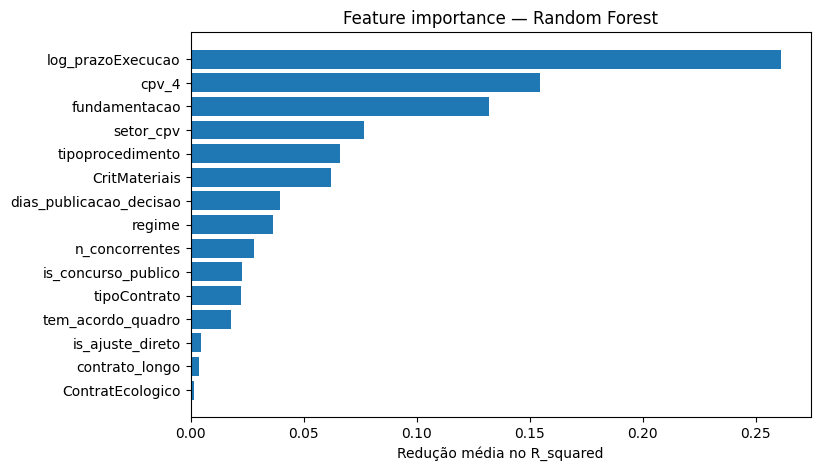

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(
    importancias["feature"].head(15)[::-1],
    importancias["importance_mean"].head(15)[::-1]
)
plt.title("Feature importance — Random Forest")
plt.xlabel("Redução média no R_squared")
plt.show()

In [ ]:
erros = X_test.copy()
erros["preco_real"] = y_test_orig.values
erros["preco_previsto"] = pred_rf_orig
erros["erro_abs"] = np.abs(erros["preco_real"] - erros["preco_previsto"])
erros["erro_pct"] = erros["erro_abs"] / erros["preco_real"]
erros["residuo"] = erros["preco_real"] - erros["preco_previsto"]
erros["ratio_real_previsto"] = (
    erros["preco_real"] / erros["preco_previsto"].replace(0, np.nan)
)

erros["residuo_log"] = (
    np.log1p(erros["preco_real"]) - np.log1p(erros["preco_previsto"])
)

erros.head()

,log_prazoExecucao,is_concurso_publico,contrato_longo,n_concorrentes,is_ajuste_direto,tem_acordo_quadro,dias_publicacao_decisao,setor_cpv,tipoprocedimento,tipoContrato,...,regime,ContratEcologico,cpv_4,preco_real,preco_previsto,erro_abs,erro_pct,residuo,ratio_real_previsto,residuo_log
1005543,1.791759,0,0,0,1,0,1.0,50.0,Ajuste Direto Regime Geral,Aquisição de serviços,...,Código dos Contratos Públicos ( DL 111-B/2017 ),Não,5000,68.178036,323.605814,255.427778,3.746482,-255.427778,0.210682,-1.545928
150023,5.902633,0,0,0,1,0,6.0,79.0,Ajuste Direto Regime Geral,Aquisição de serviços,...,Código dos Contratos Públicos (DL 18/2008),Não,7931,10000.887123,13026.574101,3025.686978,0.302542,-3025.686978,0.767730,-0.264294
1119935,5.501258,0,0,2,0,0,21.0,44.0,Consulta Prévia,Aquisição de bens móveis,...,Código dos Contratos Públicos ( DL 111-B/2017 ),Não,4411,66624.307200,24962.555493,41661.751707,0.625324,41661.751707,2.668970,0.981668
398595,6.999422,1,1,1,0,0,29.0,72.0,Concurso público,Aquisição de serviços,...,Código dos Contratos Públicos ( DL 111-B/2017 ),Não,7200,167040.584815,77957.099414,89083.485401,0.533304,89083.485401,2.142724,0.762071
742018,0.000000,0,0,0,1,0,NaN,85.0,Ajuste direto simplificado,Aquisição de serviços,...,"Decreto-Lei n. 10-A/2020, de 13.03",Não,8500,96.093883,593.610261,497.516378,5.177399,-497.516378,0.161880,-1.812228


In [ ]:
top_sobrepreco_robusto = (
    erros[
        (erros["preco_real"] >= 10_000) &
        (erros["preco_previsto"] >= 1_000)
    ]
    .sort_values(["residuo_log", "erro_abs"], ascending=False)
    .head(30)
)

top_sobrepreco_robusto[
    ["preco_real", "preco_previsto", "ratio_real_previsto", "erro_abs", "residuo_log"]
]

,preco_real,preco_previsto,ratio_real_previsto,erro_abs,residuo_log
553840,557624.655238,1930.267877,288.884596,555694.387360,5.665511
1761224,645069.112934,2235.761351,288.523242,642833.351583,5.664330
740616,456464.804765,1624.586009,280.973000,454840.218756,5.637645
880910,590469.519212,2157.350979,273.701185,588312.168233,5.611575
1757804,484411.158419,1917.040209,252.687010,482494.118210,5.531632
824904,682509.525614,2756.854382,247.568218,679752.671232,5.511325
739683,615321.295834,2588.891360,237.677527,612732.404474,5.470530
780079,680190.635013,2891.583644,235.231181,677299.051369,5.460224
490558,720995.635319,3079.709920,234.111541,717915.925399,5.455474
261536,689286.981058,3108.945346,221.710871,686178.035712,5.401054


In [23]:
# previsões do melhor modelo
pred_test_log = model_rf.predict(X_test)
pred_test_orig = np.expm1(pred_test_log)
y_test_orig = np.expm1(y_test)

df_erros = pd.DataFrame({
    "valor_real": np.array(y_test_orig),
    "valor_previsto": np.array(pred_test_orig)
})

df_erros["erro_absoluto"] = abs(df_erros["valor_real"] - df_erros["valor_previsto"])

df_erros["escalao_preco"] = pd.qcut(
    df_erros["valor_real"],
    q=4,
    labels=[
        "Contratos baixos",
        "Contratos médio-baixos",
        "Contratos médio-altos",
        "Contratos elevados"
    ]
)

erro_por_escalao = df_erros.groupby("escalao_preco").agg(
    n_contratos=("valor_real", "count"),
    valor_medio_real=("valor_real", "mean"),
    valor_mediano_real=("valor_real", "median"),
    erro_medio_absoluto=("erro_absoluto", "mean"),
    erro_mediano_absoluto=("erro_absoluto", "median")
).reset_index()

erro_por_escalao["erro_medio_relativo_%"] = (
    erro_por_escalao["erro_medio_absoluto"] / erro_por_escalao["valor_medio_real"] * 100
)

erro_por_escalao = erro_por_escalao.round(2)

erro_por_escalao

,escalao_preco,n_contratos,valor_medio_real,valor_mediano_real,erro_medio_absoluto,erro_mediano_absoluto,erro_medio_relativo_%
0,Contratos baixos,89274,986.68,706.69,3784.39,1787.06,383.55
1,Contratos médio-baixos,89272,7240.78,7207.16,5358.00,3231.94,74.00
2,Contratos médio-altos,89273,18842.39,18295.53,9917.44,8094.27,52.63
3,Contratos elevados,89273,116804.69,71805.29,77925.36,43994.55,66.71


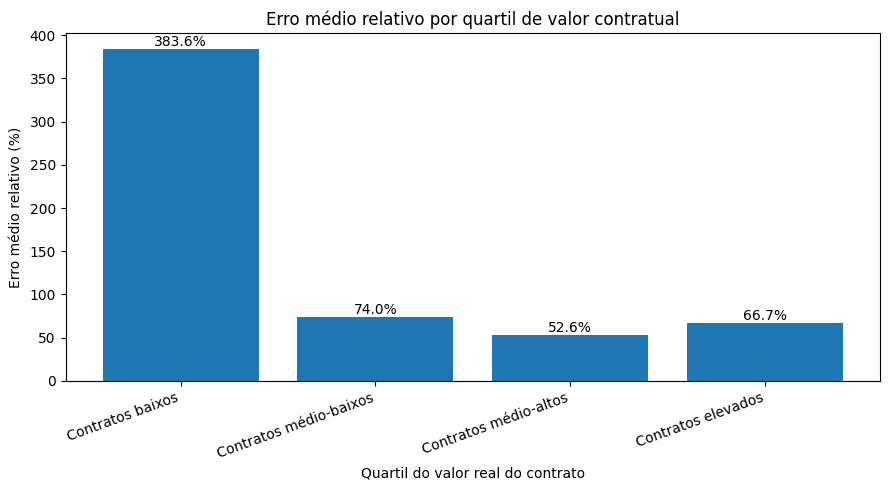

In [24]:
# Gráfico: erro médio relativo por quartil de valor real

plt.figure(figsize=(9, 5))

plt.bar(
    erro_por_escalao["escalao_preco"],
    erro_por_escalao["erro_medio_relativo_%"]
)

plt.title("Erro médio relativo por quartil de valor contratual")
plt.xlabel("Quartil do valor real do contrato")
plt.ylabel("Erro médio relativo (%)")
plt.xticks(rotation=20, ha="right")

# adicionar valores por cima das barras
for i, v in enumerate(erro_por_escalao["erro_medio_relativo_%"]):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()